In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
import pandas as pd
import numpy as np

Métricas del modelo Naive Bayes:
Accuracy : 0.3405
Recall   : 0.1990
F1       : 0.0843
Instancias procesadas: 291200


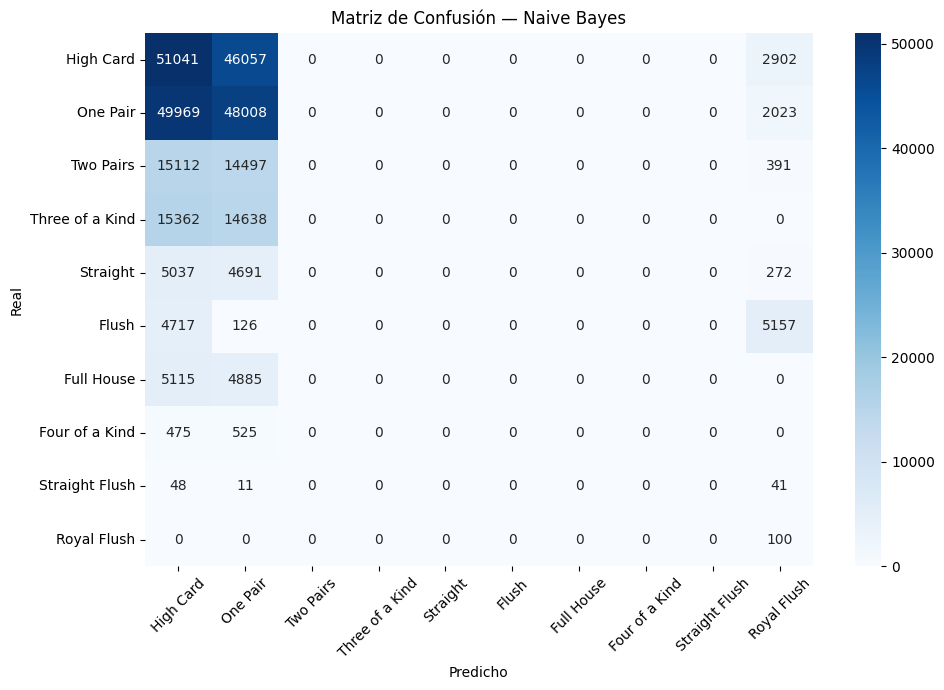

In [52]:
# 1. Cargar
df = pd.read_csv('../preprocesamiento/preprocessed_trainning.data', header=None)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

clases = sorted(y.unique().astype(int).tolist())
clase_nombres = {
    0: "High Card", 1: "One Pair", 2: "Two Pairs", 3: "Three of a Kind",
    4: "Straight",  5: "Flush",   6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}
nombres_ordenados = [clase_nombres[c] for c in clases]

# 2. GaussianNB
modelo_nb = GaussianNB()
modelo_nb.fit(x, y)
y_pred = modelo_nb.predict(x)

# 3. Métricas
print("Métricas del modelo Naive Bayes:")
print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
print(f"Recall   : {recall_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1       : {f1_score(y, y_pred, average='macro', zero_division=0):.4f}")
print("Instancias procesadas:", len(y))

# 4. Matriz de confusión
cm_nb = confusion_matrix(y, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Blues',
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)
plt.title("Matriz de Confusión — Naive Bayes")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

Iteration 1, loss = 1.44233487
Iteration 2, loss = 1.33400955
Iteration 3, loss = 1.30559414
Iteration 4, loss = 1.27832009
Iteration 5, loss = 1.25987450
Iteration 6, loss = 1.24535591
Iteration 7, loss = 1.23236298
Iteration 8, loss = 1.21988994
Iteration 9, loss = 1.20341852
Iteration 10, loss = 1.18559322
Iteration 11, loss = 1.16769428
Iteration 12, loss = 1.14523283
Iteration 13, loss = 1.11933890
Iteration 14, loss = 1.09249936
Iteration 15, loss = 1.06499548
Iteration 16, loss = 1.03539965
Iteration 17, loss = 1.00648103
Iteration 18, loss = 0.97934614
Iteration 19, loss = 0.95728542
Iteration 20, loss = 0.93794306
Iteration 21, loss = 0.92000380
Iteration 22, loss = 0.90590882
Iteration 23, loss = 0.89384970
Iteration 24, loss = 0.88197451
Iteration 25, loss = 0.87330918
Iteration 26, loss = 0.86238549
Iteration 27, loss = 0.85083938
Iteration 28, loss = 0.83947164
Iteration 29, loss = 0.82653027
Iteration 30, loss = 0.81371887
Iteration 31, loss = 0.80088090
Iteration 32, los

/home/tulocalhost/Downloads/AIProject/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy : 0.9964
Recall   : 0.9960
F1       : 0.9967


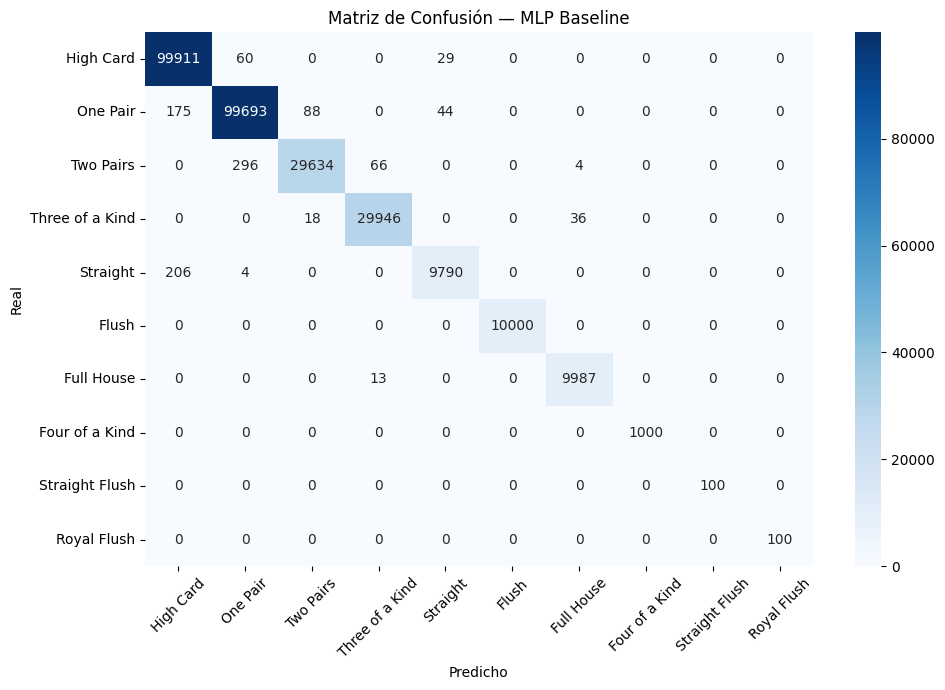

In [53]:
from sklearn.neural_network import MLPClassifier

# 1. Cargar
df = pd.read_csv('../preprocesamiento/preprocessed_trainning.data', header=None)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 2. MLP — configuración simple para baseline
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 capas ocultas
    activation='relu',
    max_iter=100,                  # épocas
    random_state=42,
    verbose=True                  # muestra loss por época
)
modelo_mlp.fit(x, y)
y_pred_mlp = modelo_mlp.predict(x)

# 3. Métricas
print(f"Accuracy : {accuracy_score(y, y_pred_mlp):.4f}")
print(f"Recall   : {recall_score(y, y_pred_mlp, average='macro', zero_division=0):.4f}")
print(f"F1       : {f1_score(y, y_pred_mlp, average='macro', zero_division=0):.4f}")

# 4. Matriz de confusión
cm_mlp = confusion_matrix(y, y_pred_mlp)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_mlp, annot=True, fmt='d', cmap='Blues',
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)
plt.title("Matriz de Confusión — MLP Baseline")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()